### Домашнє завдання: Кластеризація в Аналізі Персоналій Клієнтів

#### Контекст
В цьому ДЗ ми скористаємось алгоритмами кластеризації для задачі аналізу портретів клієнтів (Customer Personality Analysis).

Customer Personality Analysis - це аналіз різних сегментів клієнтів компанії. Цей аналіз дозволяє бізнесу краще розуміти своїх клієнтів і полегшує процес адаптації продуктів під конкретні потреби, поведінку та інтереси різних типів клієнтів.

Аналіз портретів клієнтів допомагає бізнесу змінювати свій продукт на основі цільової аудиторії, розділеної на різні сегменти. Наприклад, замість того, щоб витрачати гроші на маркетинг нового продукту для всіх клієнтів у базі даних компанії, бізнес може проаналізувати, який сегмент клієнтів найімовірніше придбає продукт, і потім зосередити маркетингові зусилля лише на цьому сегменті.

#### Завдання
На основі наданих даних в файлі `marketing_campaign.csv` потрібно виконати кластеризацію, щоб виявити сегменти клієнтів.

#### Вхідні дані
Вам надано набір даних з такими атрибутами:

**Характеристики користувачів:**
- `ID`: Унікальний ідентифікатор клієнта
- `Year_Birth`: Рік народження клієнта
- `Education`: Рівень освіти клієнта
- `Marital_Status`: Сімейний стан клієнта
- `Income`: Річний дохід домогосподарства клієнта
- `Kidhome`: Кількість дітей у домогосподарстві клієнта
- `Teenhome`: Кількість підлітків у домогосподарстві клієнта
- `Dt_Customer`: Дата реєстрації клієнта у компанії
- `Recency`: Кількість днів з моменту останньої покупки клієнта
- `Complain`: 1, якщо клієнт скаржився за останні 2 роки, 0 - якщо ні

**Продукти:**
- `MntWines`: Сума, витрачена на вино за останні 2 роки
- `MntFruits`: Сума, витрачена на фрукти за останні 2 роки
- `MntMeatProducts`: Сума, витрачена на м'ясні продукти за останні 2 роки
- `MntFishProducts`: Сума, витрачена на рибні продукти за останні 2 роки
- `MntSweetProducts`: Сума, витрачена на солодощі за останні 2 роки
- `MntGoldProds`: Сума, витрачена на золото за останні 2 роки

**Акції:**
- `NumDealsPurchases`: Кількість покупок, зроблених з використанням знижок
- `AcceptedCmp1`: 1, якщо клієнт прийняв пропозицію у першій кампанії, 0 - якщо ні
- `AcceptedCmp2`: 1, якщо клієнт прийняв пропозицію у другій кампанії, 0 - якщо ні
- `AcceptedCmp3`: 1, якщо клієнт прийняв пропозицію у третій кампанії, 0 - якщо ні
- `AcceptedCmp4`: 1, якщо клієнт прийняв пропозицію у четвертій кампанії, 0 - якщо ні
- `AcceptedCmp5`: 1, якщо клієнт прийняв пропозицію у п'ятій кампанії, 0 - якщо ні
- `Response`: 1, якщо клієнт прийняв пропозицію в останній кампанії, 0 - якщо ні

**Взаємодія з компанією:**
- `NumWebPurchases`: Кількість покупок, зроблених через вебсайт компанії
- `NumCatalogPurchases`: Кількість покупок, зроблених за каталогом
- `NumStorePurchases`: Кількість покупок, зроблених безпосередньо у магазинах
- `NumWebVisitsMonth`: Кількість відвідувань вебсайту компанії за останній місяць


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import metrics

**Завдання 1**. Завантажте дані з `marketing_campaign.csv` в Pandas dataframe і виведіть основну інформацію про дані: скільки всього рядків і колонок, які типи даних мають колонки, скільки пропущених значень.

In [4]:
df = pd.read_csv('./data/marketing_campaign.csv', delimiter="\\t", index_col='ID')
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2240 entries, 5524 to 9405
Data columns (total 28 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Year_Birth           2240 non-null   int64  
 1   Education            2240 non-null   object 
 2   Marital_Status       2240 non-null   object 
 3   Income               2216 non-null   float64
 4   Kidhome              2240 non-null   int64  
 5   Teenhome             2240 non-null   int64  
 6   Dt_Customer          2240 non-null   object 
 7   Recency              2240 non-null   int64  
 8   MntWines             2240 non-null   int64  
 9   MntFruits            2240 non-null   int64  
 10  MntMeatProducts      2240 non-null   int64  
 11  MntFishProducts      2240 non-null   int64  
 12  MntSweetProducts     2240 non-null   int64  
 13  MntGoldProds         2240 non-null   int64  
 14  NumDealsPurchases    2240 non-null   int64  
 15  NumWebPurchases      2240 non-null   int

/var/folders/vq/w1vp6s4d343cmmrh0lp122280000gn/T/ipykernel_35625/1390360016.py:1: ParserWarning: Falling back to the 'python' engine because the 'c' engine does not support regex separators (separators > 1 char and different from '\s+' are interpreted as regex); you can avoid this warning by specifying engine='python'.
  df = pd.read_csv('./data/marketing_campaign.csv', delimiter="\\t", index_col='ID')


In [5]:
df.isnull().sum()[df.isnull().sum() > 0]

Income    24
dtype: int64

In [6]:
df.describe()

,Year_Birth,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
count,2240.000000,2216.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,...,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.0,2240.0,2240.000000
mean,1968.805804,52247.251354,0.444196,0.506250,49.109375,303.935714,26.302232,166.950000,37.525446,27.062946,...,5.316518,0.072768,0.074554,0.072768,0.064286,0.013393,0.009375,3.0,11.0,0.149107
std,11.984069,25173.076661,0.538398,0.544538,28.962453,336.597393,39.773434,225.715373,54.628979,41.280498,...,2.426645,0.259813,0.262728,0.259813,0.245316,0.114976,0.096391,0.0,0.0,0.356274
min,1893.000000,1730.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
25%,1959.000000,35303.000000,0.000000,0.000000,24.000000,23.750000,1.000000,16.000000,3.000000,1.000000,...,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
50%,1970.000000,51381.500000,0.000000,0.000000,49.000000,173.500000,8.000000,67.000000,12.000000,8.000000,...,6.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
75%,1977.000000,68522.000000,1.000000,1.000000,74.000000,504.250000,33.000000,232.000000,50.000000,33.000000,...,7.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
max,1996.000000,666666.000000,2.000000,2.000000,99.000000,1493.000000,199.000000,1725.000000,259.000000,263.000000,...,20.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,3.0,11.0,1.000000


**Завдання 2.** Заповніть пропущені значення з врахуванням того завдання (кластеризація), яке ми виконуємо. Поясніть свій вибір заповнення пропущених значень.

In [8]:
df.Income.describe()

count      2216.000000
mean      52247.251354
std       25173.076661
min        1730.000000
25%       35303.000000
50%       51381.500000
75%       68522.000000
max      666666.000000
Name: Income, dtype: float64

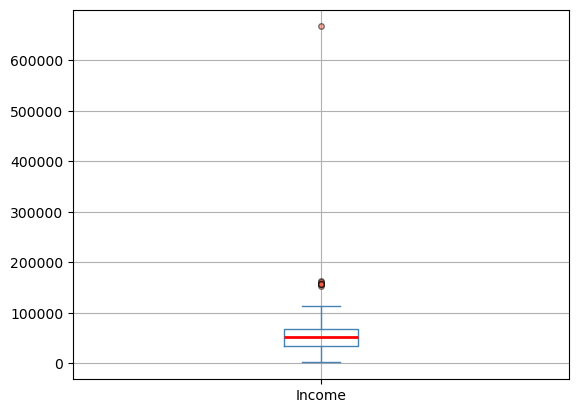

In [9]:
df.boxplot(
    column='Income',
    boxprops=dict(color='steelblue'),
    medianprops=dict(color='red', linewidth=2),
    whiskerprops=dict(color='steelblue'),
    capprops=dict(color='steelblue'),
    flierprops=dict(marker='o', markerfacecolor='tomato',
                   markersize=4, alpha=0.5)
)
plt.show();

В таблиці та на графіку чітко видно наявність досить значних аутлаєрів в колонці, тому найкращим рішенням для заповнення пустих значень буде медіана

In [11]:
df['Income'] = df['Income'].fillna(df['Income'].median())

**Завдання 3.** У нас є декілька колонок з категоріальними значеннями та одна колонка з датою. Як би ви обробили ці колонки для того, аби передати їх в алгоритм кластеризації?

Реалізуйте обробку категоріальних колонок і колонки з датою та перетворіть їх на ознаки, корисні для кластеризації з вашого погляду.

In [13]:
# Перевірка кількості категоріальних змінних
print('Number of categorical variables:', len(df.select_dtypes(include = 'object').columns))

# Перевіримо кількість унікальних значень та частку найпоширеніших значень у стовпцях
summary = df.describe(include='object').T
summary['freq_%'] = (summary['freq'].astype(float) / summary['count'].astype(float) * 100).round(2)
display(summary)
del(summary)

Number of categorical variables: 3


,count,unique,top,freq,freq_%
Education,2240,5,Graduation,1127,50.31
Marital_Status,2240,8,Married,864,38.57
Dt_Customer,2240,663,31-08-2012,12,0.54


In [14]:
# Перетворюємо Dt_Customer на datetime
df['Dt_Customer'] = pd.to_datetime(df['Dt_Customer'], dayfirst=True)

# Кількість днів клієнтства відносно найпізнішої дати в датасеті
ref_date = df['Dt_Customer'].max()
df['days_as_customer'] = (ref_date - df['Dt_Customer']).dt.days

# Оригінальна колонка більше не потрібна
df.drop(columns=['Dt_Customer'], inplace=True)

In [15]:
cat_cols = df.select_dtypes('object').columns.tolist()
print('Categorical columns:', cat_cols)

Categorical columns: ['Education', 'Marital_Status']


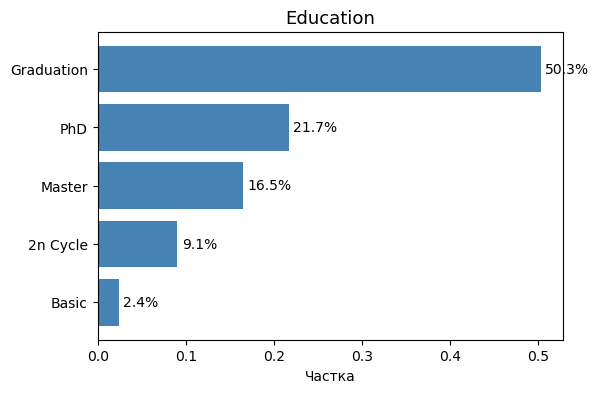

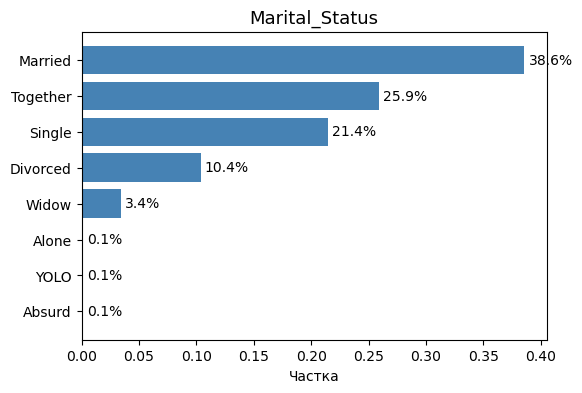

In [16]:
# Відображу частку значень в категоріях
for col in cat_cols:
    vc = df[col].value_counts(normalize=True).sort_values()

    fig, ax = plt.subplots(figsize=(6, 4))
    bars = ax.barh(vc.index, vc.values, color='steelblue')

    ax.set_title(col, fontsize=13)
    ax.set_xlabel('Частка')

    ax.bar_label(
        bars,
        labels=[f'{v:.1%}' for v in vc.values],
        padding=3
    )
    plt.show()
    plt.close(fig);

In [17]:
# Перетворимо категорійну колонку "Education" в числову
education_order = {
    'Basic':      0,
    '2n Cycle':   1,
    'Graduation': 2,
    'Master':     3,
    'PhD':        4,
}

df['Education'] = df['Education'].map(education_order)

In [18]:
# Перетворимо Marital_Status в колонку з меншою кількістю значень
df['Has_partner'] = df['Marital_Status'].isin(
    ['Married', 'Together']
).astype(int)

df.drop(columns=['Marital_Status'], inplace=True)

In [19]:
# Перевіримо основну статистику числових колонок
pd.set_option('display.max_columns', None)
df.describe()

,Year_Birth,Education,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response,days_as_customer,Has_partner
count,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.0,2240.0,2240.000000,2240.000000,2240.000000
mean,1968.805804,2.460268,52237.975446,0.444196,0.506250,49.109375,303.935714,26.302232,166.950000,37.525446,27.062946,44.021875,2.325000,4.084821,2.662054,5.790179,5.316518,0.072768,0.074554,0.072768,0.064286,0.013393,0.009375,3.0,11.0,0.149107,353.582143,0.644643
std,11.984069,1.004337,25037.955891,0.538398,0.544538,28.962453,336.597393,39.773434,225.715373,54.628979,41.280498,52.167439,1.932238,2.778714,2.923101,3.250958,2.426645,0.259813,0.262728,0.259813,0.245316,0.114976,0.096391,0.0,0.0,0.356274,202.122512,0.478728
min,1893.000000,0.000000,1730.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000,0.000000,0.000000
25%,1959.000000,2.000000,35538.750000,0.000000,0.000000,24.000000,23.750000,1.000000,16.000000,3.000000,1.000000,9.000000,1.000000,2.000000,0.000000,3.000000,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000,180.750000,0.000000
50%,1970.000000,2.000000,51381.500000,0.000000,0.000000,49.000000,173.500000,8.000000,67.000000,12.000000,8.000000,24.000000,2.000000,4.000000,2.000000,5.000000,6.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000,355.500000,1.000000
75%,1977.000000,3.000000,68289.750000,1.000000,1.000000,74.000000,504.250000,33.000000,232.000000,50.000000,33.000000,56.000000,3.000000,6.000000,4.000000,8.000000,7.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000,529.000000,1.000000
max,1996.000000,4.000000,666666.000000,2.000000,2.000000,99.000000,1493.000000,199.000000,1725.000000,259.000000,263.000000,362.000000,15.000000,27.000000,28.000000,13.000000,20.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,3.0,11.0,1.000000,699.000000,1.000000


In [20]:
# Колонка Complain в 75 персентилі має значення 0. Перевіримо кількість значень в цій колонці
df.Complain.value_counts()

Complain
0    2219
1      21
Name: count, dtype: int64

Отже, колонка Complain не є інформативною в даному випадку. Також не є інформативними колонки Z_CostContact та Z_Revenue, адже вони мають тільки одне значення. Тому всі ці стовпці будуть видалені

In [22]:
df.drop(columns=['Z_CostContact', 'Z_Revenue', 'Complain'], 
        inplace=True)

In [23]:
# Всі AcceptedCmp — бінарні флаги однієї природи, тому варто їх просумувати
cmp_cols = ['AcceptedCmp1', 'AcceptedCmp2', 'AcceptedCmp3',
            'AcceptedCmp4', 'AcceptedCmp5', 'Response']
df['TotalAcceptedCmp'] = df[cmp_cols].sum(axis=1)
df.drop(columns=cmp_cols, inplace=True)
df['TotalAcceptedCmp'].value_counts()

TotalAcceptedCmp
0    1631
1     370
2     142
3      51
4      36
5      10
Name: count, dtype: int64

In [24]:
# Year_Birth — сам по собі не інформативний для кластеризації. Краще відобразимо вік клієнта
df['Age'] = 2026 - df['Year_Birth']
df.drop(columns=['Year_Birth'], inplace=True)

In [25]:
# Kidhome і Teenhome мають досить схоже значення наявності дітей у клієнта. Об'єднаємо їх
df['TotalChildren'] = df['Kidhome'] + df['Teenhome']
df.drop(columns=['Kidhome', 'Teenhome'], inplace=True)
df['TotalChildren'].value_counts()

TotalChildren
1    1128
0     638
2     421
3      53
Name: count, dtype: int64

In [26]:
# Відобразимо кореляцію числових значень
num_cols = df.select_dtypes(include='number').columns
print('Number of numerical variables:', len(num_cols))

corr = df[num_cols].corr()

# Беремо тільки верхній трикутник без діагоналі
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)

# Перетворюємо в "плоский" формат
corr_pairs = (
    corr.where(mask)
        .stack()
        .reset_index()
)

corr_pairs.columns = ['feature_1', 'feature_2', 'correlation']

# Сортуємо по силі кореляції
corr_pairs = corr_pairs.reindex(
    corr_pairs['correlation'].abs().sort_values(ascending=False).index
)

corr_pairs[corr_pairs['correlation']>=0.5].sort_values(by=['feature_1', 'correlation'])

Number of numerical variables: 19


,feature_1,feature_2,correlation
28,Income,NumStorePurchases,0.526600
19,Income,MntWines,0.576903
21,Income,MntMeatProducts,0.577805
27,Income,NumCatalogPurchases,0.586826
97,MntFishProducts,NumCatalogPurchases,0.534478
93,MntFishProducts,MntSweetProducts,0.579870
66,MntFruits,MntMeatProducts,0.543105
68,MntFruits,MntSweetProducts,0.567164
67,MntFruits,MntFishProducts,0.594804
81,MntMeatProducts,MntSweetProducts,0.523846


In [27]:
# MntFruits, MntFish, MntSweet, MntMeat мають взаємні кореляції 0.5+. Об'єднуємо в загальні витрати на їжу
df['MntFood'] = (df['MntFruits'] + df['MntFishProducts']
              + df['MntSweetProducts'] + df['MntMeatProducts'])

df.drop(columns=['MntFruits', 'MntFishProducts', 'MntSweetProducts', 'MntMeatProducts'], 
        inplace=True)

Перевіримо чи є сенс окремо відображати джерело Purchases по клієнту

In [29]:
df['HasWebPurchases'] = (df['NumWebPurchases'] > 0).astype(int)
df['HasCatalogPurchases'] = (df['NumCatalogPurchases'] > 0).astype(int)
df['HasStorePurchases'] = (df['NumStorePurchases'] > 0).astype(int)

In [30]:
(df['HasWebPurchases'] + df['HasCatalogPurchases'] + df['HasStorePurchases']).value_counts()

3    1642
2     552
1      40
0       6
Name: count, dtype: int64

Як бачимо, більшість клієнтів робить покупки мінімум з 2 джерел, тому немає сенсу додавати дану категорію

In [32]:
df.drop(columns=['HasWebPurchases', 'HasCatalogPurchases', 'HasStorePurchases'], 
        inplace=True)

In [33]:
# NumCatalog + NumStore + NumWeb = NumPurchases
df['NumPurchases'] = (df['NumCatalogPurchases'] + df['NumStorePurchases']
                  + df['NumWebPurchases'])

df.drop(columns=['NumCatalogPurchases', 'NumStorePurchases', 'NumWebPurchases'], 
        inplace=True)

Перевіримо кореляцію оновлених колонок

In [35]:
num_cols = df.select_dtypes(include='number').columns
print('Number of numerical variables:', len(num_cols))

corr = df[num_cols].corr()

# Беремо тільки верхній трикутник без діагоналі
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)

# Перетворюємо в "плоский" формат
corr_pairs = (
    corr.where(mask)
        .stack()
        .reset_index()
)

corr_pairs.columns = ['feature_1', 'feature_2', 'correlation']

# Сортуємо по силі кореляції
corr_pairs = corr_pairs.reindex(
    corr_pairs['correlation'].abs().sort_values(ascending=False).index
)

corr_pairs[corr_pairs['correlation']>=0.5].sort_values(by=['feature_1', 'correlation'])

Number of numerical variables: 14


,feature_1,feature_2,correlation
14,Income,MntWines,0.576903
23,Income,MntFood,0.605540
24,Income,NumPurchases,0.622386
90,MntFood,NumPurchases,0.680720
54,MntGoldProds,NumPurchases,0.512427
44,MntWines,MntFood,0.576490
45,MntWines,NumPurchases,0.756490


In [36]:
# MntWines і MntFood корелюють 0.58, обидва корелюють з NumPurchases 0.76/0.68. Об'єднуємо всі витрати в одну суму для подальшого розрахунку середнього чеку
df['TotalMnt'] = df['MntWines'] + df['MntFood'] + df['MntGoldProds']
df.drop(columns=['MntWines', 'MntFood', 'MntGoldProds'], inplace=True)

# +1 щоб уникнути ділення на нуль
df['AvgSpendPerPurchase'] = df['TotalMnt'] / (df['NumPurchases']+1)

df.drop(columns=['NumPurchases', 'TotalMnt'], inplace=True)

print(df['AvgSpendPerPurchase'].describe().round(2))

count    2240.00
mean       35.03
std        33.16
min         2.00
25%        10.86
50%        27.56
75%        47.17
max       839.50
Name: AvgSpendPerPurchase, dtype: float64


Number of numerical variables: 11


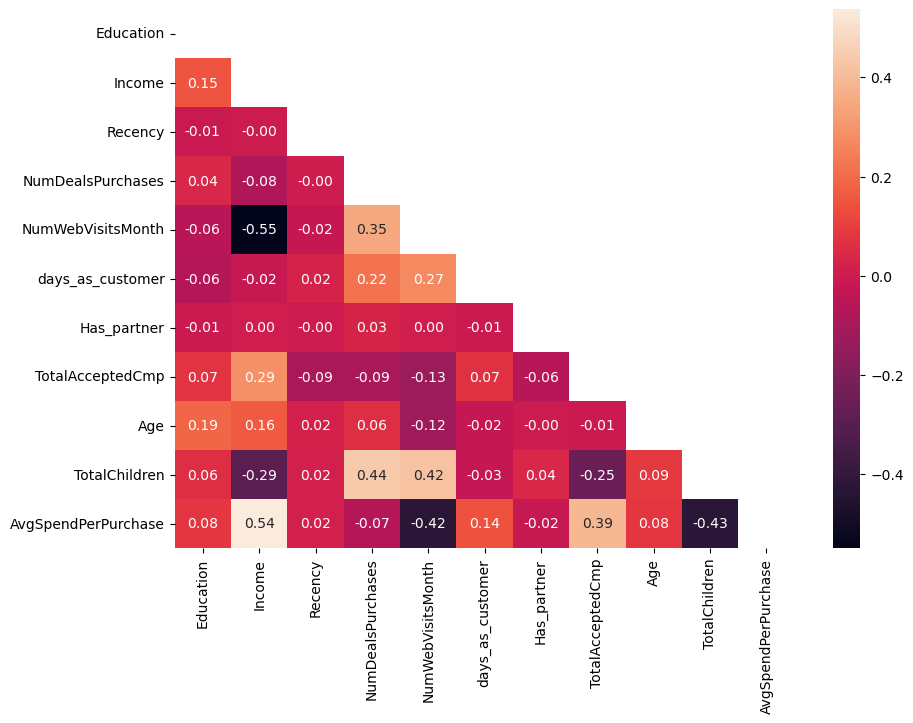

In [37]:
# Оновлена кореляційна матриця
num_cols = df.select_dtypes(include='number').columns
print('Number of numerical variables:', len(num_cols))

corr = df[num_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
plt.figure(figsize = (10,7))
sns.heatmap(data = corr, mask=mask, annot = True, cbar = True, fmt='.2f')
plt.show();

**Завдання 4**.
1. Запишіть в змінну X ті дані, які будете кластеризувати.
2. Побудуйте кластеризацію з KMeans на 3 кластери.
3. Обчисліть метрику силуету для цієї кластеризації.

In [39]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

X = df.copy()
kmeans = KMeans(n_clusters=3, random_state=42, n_init='auto')
kmeans.fit(X)

labels = kmeans.predict(X)
print(labels)

[2 0 2 ... 2 2 2]


In [40]:
centroids = kmeans.cluster_centers_
s = metrics.silhouette_score(X, labels, metric='euclidean')
print(f'Silhouette Coefficient for the data Dataset Clusters: {s:.2f}')

Silhouette Coefficient for the data Dataset Clusters: 0.60


**Завдання 5.** Візуалізуйте знайдені кластери разом з наявними даними та проаналізуйте кластери. У нас ознак більше, ніж 2 або 3, тож, тут треба подумати, які саме ознаки варто використати для візуалізації аби вони були інформативними. Рекомендую точно звернути увагу на харакетиристики про дохід користувачів і те, як вони взаємодять з магазинок (кількість покупок і тд).

Для візуалізації зручно може бути використати `plotly.express.scatter_3d` для 3D графіку розсіювання, але тут можна скористатись будь-яким зрозумілим і зручним для вас методом візуалізації. Опишіть свої спостереження, чи кластери мають сенс?

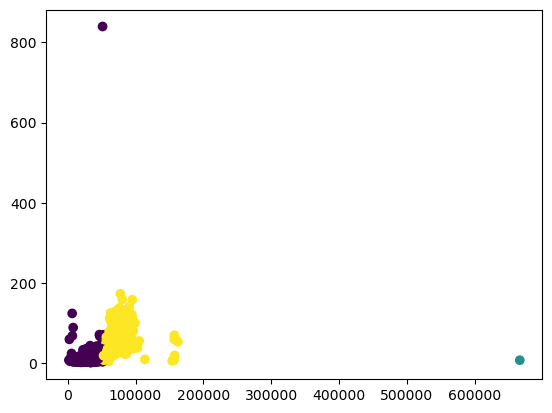

In [42]:
plt.scatter(X['Income'], X['AvgSpendPerPurchase'], c=labels) 
plt.show()

На графіку чітко видно, що кластеризація поки відбувається чисто в межах Income, що не дає більш глобального розуміння поведінки клієнта, тому продавжую подальші експерименти

**Завдання 6**. Масштабуйте дані (StandardScaler/MinMaxScaler) і побудуйте знову кластеризацію KMeans на 3 кластери і обчисліть метрику силуету. Опишіть порівняння з експериментом без масштабування значень.

In [45]:
from sklearn.preprocessing import StandardScaler

In [46]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

kmeans_scaled = KMeans(n_clusters=3, n_init='auto')
kmeans_scaled.fit(X_scaled)

labels_scaled = kmeans_scaled.predict(X_scaled)
print(labels_scaled)

[0 1 0 ... 0 1 1]


In [47]:
centroids = kmeans_scaled.cluster_centers_
s = metrics.silhouette_score(X_scaled, labels_scaled, metric='euclidean')
print(f'Silhouette Coefficient for the data Dataset Clusters: {s:.3f}')

Silhouette Coefficient for the data Dataset Clusters: 0.122


Бачимо, що Silhouette Coefficient на масштабованих даних значно менший. Це пояснюється тим, що Income повністю поглинає всі інші ознаки за рахунок своєї величини

**Завдання 7.** З візуалізацій на попередньому кроці ви могли побачити якісь викиди в даних. Опрацюйте викиди (можна видалити ці рядки або придумати інший спосіб).

In [50]:
df.describe(percentiles=[0.25, 0.5, 0.75, 0.99, 0.999])

,Education,Income,Recency,NumDealsPurchases,NumWebVisitsMonth,days_as_customer,Has_partner,TotalAcceptedCmp,Age,TotalChildren,AvgSpendPerPurchase
count,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000
mean,2.460268,52237.975446,49.109375,2.325000,5.316518,353.582143,0.644643,0.446875,57.194196,0.950446,35.032810
std,1.004337,25037.955891,28.962453,1.932238,2.426645,202.122512,0.478728,0.890543,11.984069,0.751803,33.162929
min,0.000000,1730.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,30.000000,0.000000,2.000000
25%,2.000000,35538.750000,24.000000,1.000000,3.000000,180.750000,0.000000,0.000000,49.000000,0.000000,10.857143
50%,2.000000,51381.500000,49.000000,2.000000,6.000000,355.500000,1.000000,0.000000,56.000000,1.000000,27.560897
75%,3.000000,68289.750000,74.000000,3.000000,7.000000,529.000000,1.000000,1.000000,67.000000,1.000000,47.170000
99%,4.000000,94437.680000,98.000000,10.000000,9.000000,691.000000,1.000000,4.000000,81.000000,3.000000,120.174375
99.9%,4.000000,160069.270000,99.000000,15.000000,19.761000,697.000000,1.000000,5.000000,116.440000,3.000000,159.132369
max,4.000000,666666.000000,99.000000,15.000000,20.000000,699.000000,1.000000,5.000000,133.000000,3.000000,839.500000


В таблиці можна побачити 3 колонки з явними викидами. Розберемо їх детальніше

In [52]:
# Один запис з доходом 666 666 при медіані $51 382 — очевидна помилка вводу
# Наступне найбільше значення: ~$162k → відфільтровуємо > $200k
df = df[df['Income'] <= df['Income'].quantile(0.999)]

In [53]:
#  Клієнти з віком більше 90 років - явна помилка в даних
df = df[df['Age'] <= 90]

In [54]:
# AvgSpendPerPurchase має явний аутлаєр, але він дуже схожий на реальні дані. 
# Оскільки відмінність цього значення від 99.9 персентиля досить значна, просто прирівняємо аутлаєр до 99.9 персентиля
cap = df['AvgSpendPerPurchase'].quantile(0.999)
df['AvgSpendPerPurchase'] = df['AvgSpendPerPurchase'].clip(upper=cap)

In [55]:
# оновимо датасети
X = df.copy()
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

**Завдання 8.** Виконайте Elbow method для пошуку оптимальної кількості кластерів та натренуйте KMeans з тою кількістю кластерів, яку Elbow method показав як оптимальну. Обчисліть метрику силуету. Візуалізуйте кластери. З яким набором даних (масштабованим чи ні) тут працювати - ваш вибір, можна зробити експеримент з обома.

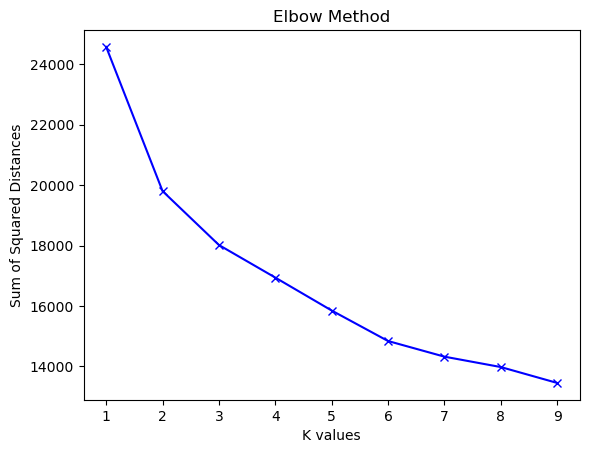

In [57]:
K = range(1,10)
sum_of_squared_distances = []

for k in K:
    model = KMeans(n_clusters=k, n_init='auto').fit(X_scaled)
    sum_of_squared_distances.append(model.inertia_)

plt.plot(K, sum_of_squared_distances, 'bx-')
plt.xlabel('K values')  # Значення K
plt.ylabel('Sum of Squared Distances')  # Сума квадратів відстаней
plt.title('Elbow Method')  # Метод ліктя
plt.show()

Крива має лікоть на рівні k ≈ 3–4. Тому оптимальна кількість кластерів - 3 або 4.

**Завдання 9.** Використовуючи методи `scipy` `dendrogram, linkage, fcluster`
1. Побудуйте ієрархічну агломеративну кластеризацію з `single linkage` на даних невідмасштабованих, але з прибраним викидом.
2. Візуалізуйте дендрограму. При візуалізації обовʼязково задайте параметр `truncate_mode='lastp'` - це обріже дендрограму, без цього вона буде завелика, бо у нас тут даних суттєво більше, ніж в лекції.
3. Проаналізуйте дендрограму та побудуйте варіанти плоских кластеризацій з `fcluster` на 2 і 3 кластери. Візуалізуйте результати кожної з цих кластеризацій та зробіть висновок. Чи вважаєте ви якусь з цих кластеризацій вдалою? Що спостерігаєте з цих кластеризацій?
4. Порахуйте мерику силуету для цього методу кластеризації.

In [60]:
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster

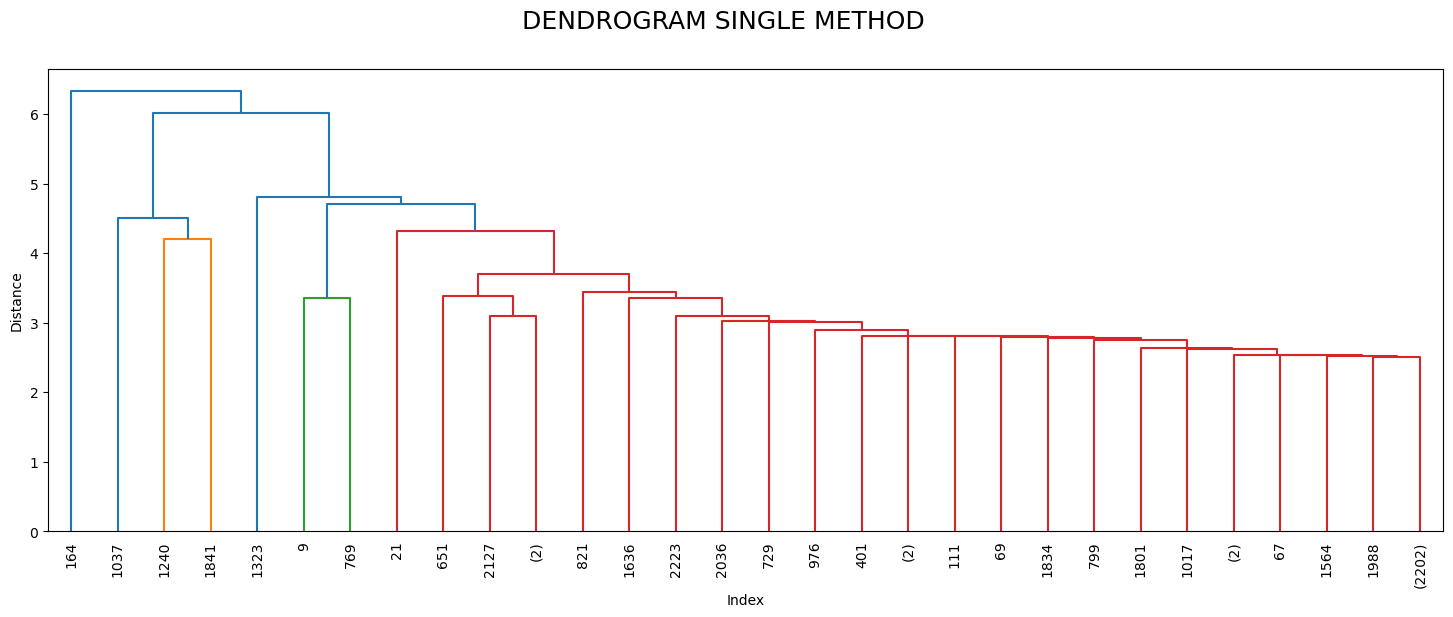

In [61]:
dist_sin = linkage(X_scaled, method="single")
plt.figure(figsize=(18,6))
dendrogram(dist_sin, leaf_rotation=90, truncate_mode='lastp')
plt.xlabel('Index')
plt.ylabel('Distance')
plt.suptitle("DENDROGRAM SINGLE METHOD",fontsize=18)
plt.show();

In [62]:
X['2_clust'] = fcluster(dist_sin, 2, criterion='maxclust')
X['3_clust'] = fcluster(dist_sin, 3, criterion='maxclust')

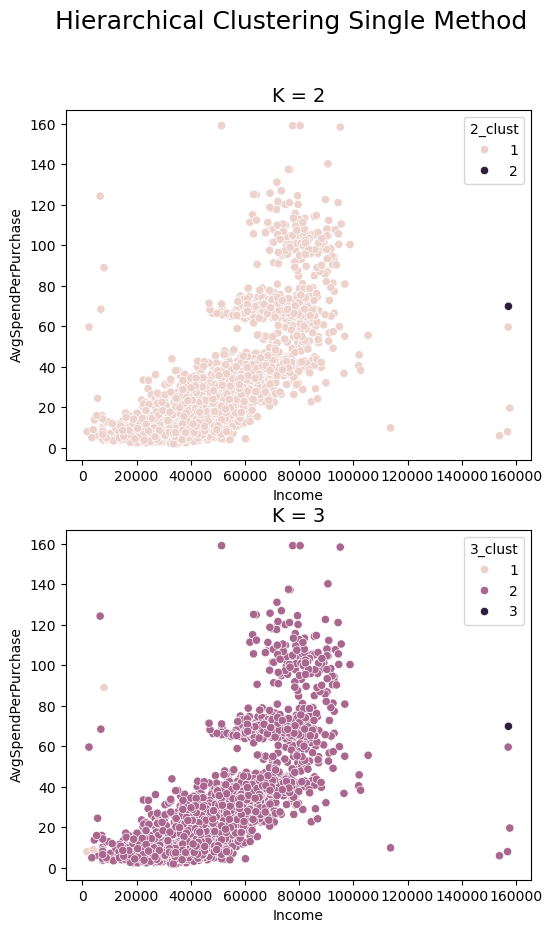

In [63]:
plt.figure(figsize=(6,10))

plt.suptitle("Hierarchical Clustering Single Method",fontsize=18)

plt.subplot(2,1,1)
plt.title("K = 2",fontsize=14)
sns.scatterplot(x="Income",y="AvgSpendPerPurchase", data=X, hue="2_clust")

plt.subplot(2,1,2)
plt.title("K = 3",fontsize=14)
sns.scatterplot(x="Income",y="AvgSpendPerPurchase", data=X, hue="3_clust")

plt.show();

In [64]:
X['2_clust'].value_counts(), X['3_clust'].value_counts()

(2_clust
 1    2233
 2       1
 Name: count, dtype: int64,
 3_clust
 2    2230
 1       3
 3       1
 Name: count, dtype: int64)

Як бачимо, абсолютна більшість точок знаходиться в одному кластері, що не дає жодної інформативності, тому дана кластеризація не є доцільною

**Завдання 10.**
1. Використайте метод кластеризації, який ми не використовували в попередніх завданнях цього ДЗ (може бути ієрархічна кластеризація з іншим способом звʼязності або інші методи sklearn).
2. Порахуйте метрику силуету і візуалізуйте результат кластеризації. Зробіть висновок про те, чи могла б ця кластеризація бути корисною?

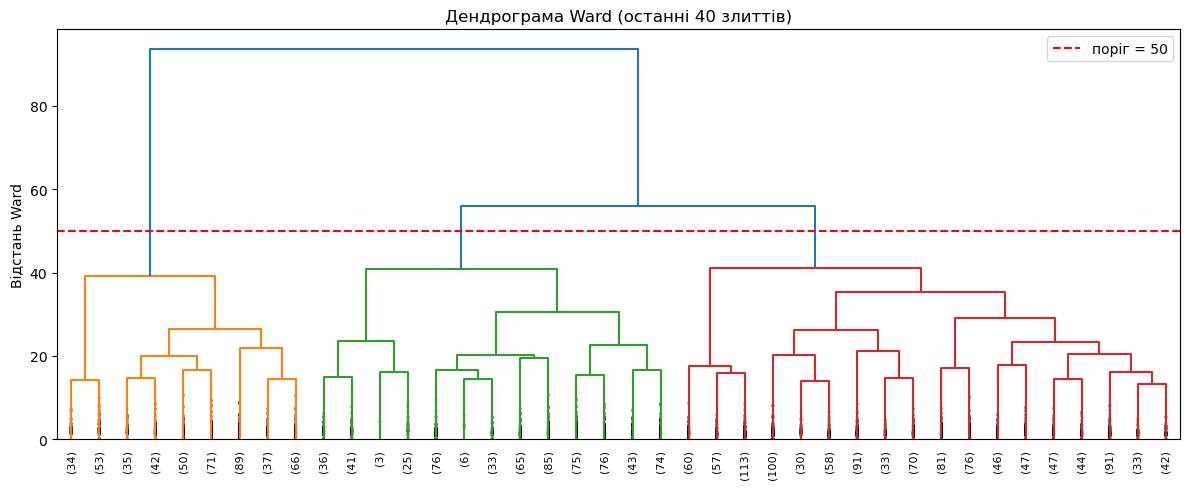

In [67]:
dist_ward = linkage(X_scaled, method='ward')

plt.figure(figsize=(12, 5))
dendrogram(
    dist_ward,
    truncate_mode='lastp',
    p=40,
    leaf_rotation=90,
    show_contracted=True,
    color_threshold=50
)
plt.axhline(y=50, color='red', linestyle='--', label='поріг = 50')
plt.title('Дендрограма Ward (останні 40 злиттів)')
plt.ylabel('Відстань Ward')
plt.legend()
plt.tight_layout()
plt.show()

In [68]:
labels = fcluster(dist_ward, t=2, criterion='maxclust') - 1

df['Cluster'] = labels
score = silhouette_score(X_scaled, labels)

print(f'Silhouette: {score:.4f}')
print(df['Cluster'].value_counts().sort_index())

Silhouette: 0.2254
Cluster
0     477
1    1757
Name: count, dtype: int64


In [69]:
for n in range(2, 6):
    lbl = fcluster(dist_ward, t=n, criterion='maxclust') - 1
    s = silhouette_score(X_scaled, lbl)
    sizes = pd.Series(lbl).value_counts().sort_index().tolist()
    print(f'n={n}: silhouette={s:.3f}, розміри={sizes}')

n=2: silhouette=0.225, розміри=[477, 1757]
n=3: silhouette=0.134, розміри=[477, 638, 1119]
n=4: silhouette=0.081, розміри=[477, 638, 230, 889]
n=5: silhouette=0.090, розміри=[477, 105, 533, 230, 889]


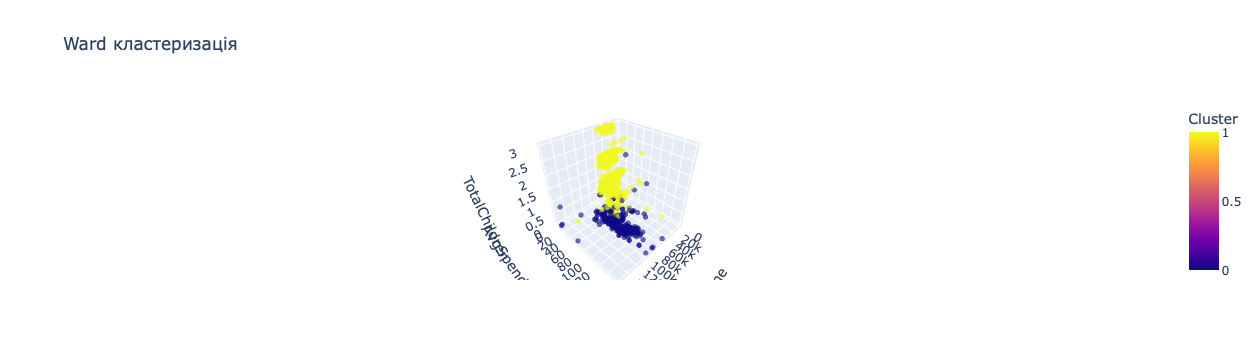

In [70]:
import plotly.express as px

fig = px.scatter_3d(
    df,
    x='Income',
    y='AvgSpendPerPurchase',
    z='TotalChildren',
    color='Cluster',
    opacity=0.6,
    title='Ward кластеризація'
)

fig.update_traces(marker=dict(size=3))
fig.update_layout(legend_title_text='Cluster')
fig.show()

Отже, Ward кластеризація з 2 кластерами показала найкраще з наявних на даний момент значень silhouette - 0.225, але досі виглядає так, що можна знайти кластеризацію покраще